# Crop Recommendation System for Thanjavur District
## Predicting Best Crops Based on Soil & Weather Conditions for Maximum Yield

## 1. Import Libraries and Load Data

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
import glob

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Define base path
data_path = Path(r'c:\Users\tanis\Documents\Project 2\Project---2\Data')
print(f"Data path: {data_path}")

Data path: c:\Users\tanis\Documents\Project 2\Project---2\Data


## 2. Load Thanjavur Soil Data

In [21]:
# Load Thanjavur soil data
soil_file = data_path / 'Soil Data ( District Wise)' / 'CSV Format' / 'THANJAVUR.csv'
soil_data = pd.read_csv(soil_file)

print(f"Soil Data Shape: {soil_data.shape}")
print(f"\nDistrict: {soil_data['District'].unique()}")
print(f"\nBlocks: {soil_data['Block'].unique()}")
print(f"\nSoil Data Summary:")
soil_data.head()

Soil Data Shape: (14, 34)

District: <StringArray>
['THANJAVUR']
Length: 1, dtype: str

Blocks: <StringArray>
[       'AMMAPETTAI',           'BUDALUR',        'KUMBAKONAM',
          'MADUKKUR',        'ORATTANADU',         'PAPANASAM',
      'PATTUKKOTTAI',        'PERAVURANI', 'SETHUBHAVACHATRAM',
         'THANJAVUR',    'THIRUPPANANDAL',      'THIRUVAIYARU',
        'THIRUVONAM',  'TIRUVIDAIMARUDUR']
Length: 14, dtype: str

Soil Data Summary:


,State,District,Block,Scheme,Cycle,n_High,n_Medium,n_Low,p_High,p_Medium,...,Fe_Sufficient,Fe_Deficient,Zn_Sufficient,Zn_Deficient,Cu_Sufficient,Cu_Deficient,B_Sufficient,B_Deficient,Mn_Sufficient,Mn_Deficient
0,AMMAPETTAI,THANJAVUR,AMMAPETTAI,NaN,2025-26,0.00,0.00,100.00,5.82,19.71,...,63.65,36.35,49.00,51.00,97.12,2.88,33.29,66.71,27.24,72.76
1,BUDALUR,THANJAVUR,BUDALUR,NaN,2025-26,0.00,0.00,100.00,8.10,12.04,...,86.90,13.10,40.14,59.86,97.25,2.75,26.20,73.80,32.39,67.61
2,KUMBAKONAM,THANJAVUR,KUMBAKONAM,NaN,2025-26,0.00,0.00,100.00,1.24,21.99,...,87.39,12.61,35.10,64.90,98.67,1.33,26.39,73.61,27.80,72.20
3,MADUKKUR,THANJAVUR,MADUKKUR,NaN,2025-26,0.00,0.31,99.69,3.94,20.00,...,71.81,28.19,31.09,68.91,98.13,1.87,23.94,76.06,24.97,75.03
4,ORATTANADU,THANJAVUR,ORATTANADU,NaN,2025-26,0.04,0.00,99.96,34.07,11.55,...,65.97,34.03,35.40,64.60,96.55,3.45,25.27,74.73,27.08,72.92


## 3. Load Thanjavur Weather Data

In [22]:
# Load weather data for Thanjavur
weather_file = data_path / 'Weather Data (District Wise)' / 'weather_data_all_blocks.csv'
weather_data = pd.read_csv(weather_file)

# Filter for Thanjavur district
ariyalur_weather = weather_data[weather_data['district'] == 'Thanjavur'].copy()

print(f"Total Weather Records: {len(weather_data)}")
print(f"Thanjavur Weather Records: {len(ariyalur_weather)}")
print(f"\nThanjavur Blocks: {ariyalur_weather['block'].unique()}")
print(f"\nWeather Data Columns: {len(ariyalur_weather.columns)}")
print(f"\nSample Weather Data:")
ariyalur_weather[['block', 'temp_max_mean', 'temp_min_mean', 'total_rainfall_mm', 'humidity_max_mean']].head()

Total Weather Records: 97
Thanjavur Weather Records: 14

Thanjavur Blocks: <StringArray>
[       'Ammapettai',           'Budalur',        'Kumbakonam',
          'Madukkur',        'Orattanadu',         'Papanasam',
      'Pattukkottai',        'Peravurani', 'Sethubhavachatram',
         'Thanjavur',    'Thiruppanandal',      'Thiruvaiyaru',
        'Thiruvonam',  'Tiruvidaimarudur']
Length: 14, dtype: str

Weather Data Columns: 37

Sample Weather Data:


,block,temp_max_mean,temp_min_mean,total_rainfall_mm,humidity_max_mean
32,Ammapettai,32.4861,24.1973,1343.3,90.9863
33,Budalur,33.0669,24.2085,1255.3,89.0273
34,Kumbakonam,32.4421,24.2388,1319.6,91.3333
35,Madukkur,32.1631,24.2902,1588.8,93.3197
36,Orattanadu,32.5339,24.4049,1445.8,91.3142


## 4. Load Rice Crop Requirements

In [ ]:
# Load rice crop requirements
rice_file = data_path / 'Crop Data' / 'Rice.csv'
rice_data = pd.read_csv(rice_file)

print(f"Rice Varieties: {len(rice_data)}")
print(f"\nRice Crop Requirements:")
print(rice_data[['Variety', 'Primary Season', 'Duration (Days)', 'N', 'P', 'K', 'pH_Low', 'pH_High']].head(10))

## 5. Load All Crop Price Data

In [8]:
# Load all cleaned crop CSVs
crop_files = glob.glob(str(data_path / '3_Cleaned CSVs' / '*.csv'))
print(f"Total crop files found: {len(crop_files)}")

# Load all crop data
crop_data_dict = {}
for file in crop_files:
    crop_name = Path(file).stem
    try:
        df = pd.read_csv(file)
        crop_data_dict[crop_name] = df
    except Exception as e:
        print(f"Error loading {crop_name}: {e}")

print(f"\nSuccessfully loaded {len(crop_data_dict)} crops")
print(f"\nCrops available: {sorted(crop_data_dict.keys())[:10]}...")

Total crop files found: 47

Successfully loaded 47 crops

Crops available: ['Bajra-2015-2019', 'Bajra-2019-2022', 'Bajra-2022-2025', 'Banana', 'Banana - Green', 'Blackgram-2015-2019', 'Blackgram-2019-2022', 'Blackgram-2022-2025', 'Cashewnuts', 'Coconut-2015-2019']...


## 6. Analyze Thanjavur Soil Conditions

Thanjavur Soil Summary (% distribution):
           n_High  n_Medium  n_Low  p_High  p_Medium  p_Low  k_High  k_Medium  \
District                                                                        
THANJAVUR    0.01      0.26  99.73    6.07     18.39  75.54   26.74     49.79   

           k_Low  pH_Neutral  pH_Acidic  pH_Alkaline  EC_Saline  EC_NonSaline  \
District                                                                        
THANJAVUR  23.47       97.82       1.42         0.75       0.43         99.57   

           OC_High  OC_Medium  OC_Low  
District                               
THANJAVUR     6.74      29.91   63.35  


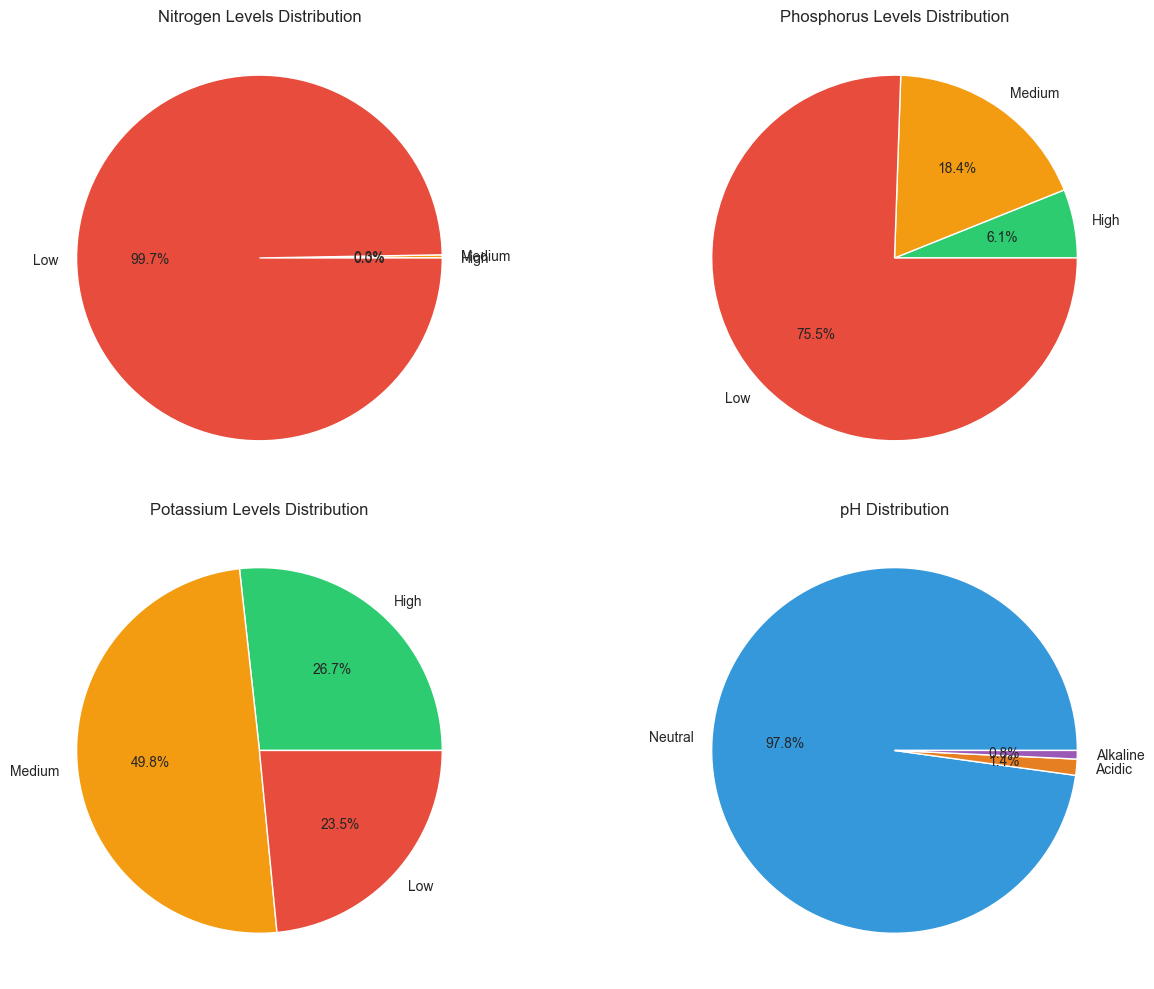

In [24]:
# Aggregate soil conditions for Thanjavur district
soil_summary = soil_data.groupby('District')[[
    'n_High', 'n_Medium', 'n_Low',
    'p_High', 'p_Medium', 'p_Low',
    'k_High', 'k_Medium', 'k_Low',
    'pH_Neutral', 'pH_Acidic', 'pH_Alkaline',
    'EC_Saline', 'EC_NonSaline',
    'OC_High', 'OC_Medium', 'OC_Low'
]].mean()

print("Thanjavur Soil Summary (% distribution):")
print(soil_summary.round(2))

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Nitrogen levels
ax = axes[0, 0]
n_data = [soil_summary.loc['THANJAVUR', 'n_High'], 
          soil_summary.loc['THANJAVUR', 'n_Medium'], 
          soil_summary.loc['THANJAVUR', 'n_Low']]
ax.pie(n_data, labels=['High', 'Medium', 'Low'], autopct='%1.1f%%', colors=['#2ecc71', '#f39c12', '#e74c3c'])
ax.set_title('Nitrogen Levels Distribution')

# Phosphorus levels
ax = axes[0, 1]
p_data = [soil_summary.loc['THANJAVUR', 'p_High'], 
          soil_summary.loc['THANJAVUR', 'p_Medium'], 
          soil_summary.loc['THANJAVUR', 'p_Low']]
ax.pie(p_data, labels=['High', 'Medium', 'Low'], autopct='%1.1f%%', colors=['#2ecc71', '#f39c12', '#e74c3c'])
ax.set_title('Phosphorus Levels Distribution')

# Potassium levels
ax = axes[1, 0]
k_data = [soil_summary.loc['THANJAVUR', 'k_High'], 
          soil_summary.loc['THANJAVUR', 'k_Medium'], 
          soil_summary.loc['THANJAVUR', 'k_Low']]
ax.pie(k_data, labels=['High', 'Medium', 'Low'], autopct='%1.1f%%', colors=['#2ecc71', '#f39c12', '#e74c3c'])
ax.set_title('Potassium Levels Distribution')

# pH levels
ax = axes[1, 1]
ph_data = [soil_summary.loc['THANJAVUR', 'pH_Neutral'], 
           soil_summary.loc['THANJAVUR', 'pH_Acidic'], 
           soil_summary.loc['THANJAVUR', 'pH_Alkaline']]
ax.pie(ph_data, labels=['Neutral', 'Acidic', 'Alkaline'], autopct='%1.1f%%', colors=['#3498db', '#e67e22', '#9b59b6'])
ax.set_title('pH Distribution')

plt.tight_layout()
plt.show()

## 7. Analyze Thanjavur Weather Conditions


Thanjavur Weather Summary:
temp_max_mean              32.44
temp_min_mean              24.27
temp_mean_annual           27.77
total_rainfall_mm        1412.04
avg_daily_rainfall_mm       3.86
humidity_max_mean          91.39
humidity_min_mean          52.70
rainy_days                235.07
wind_speed_max_mean        18.90
dtype: float64


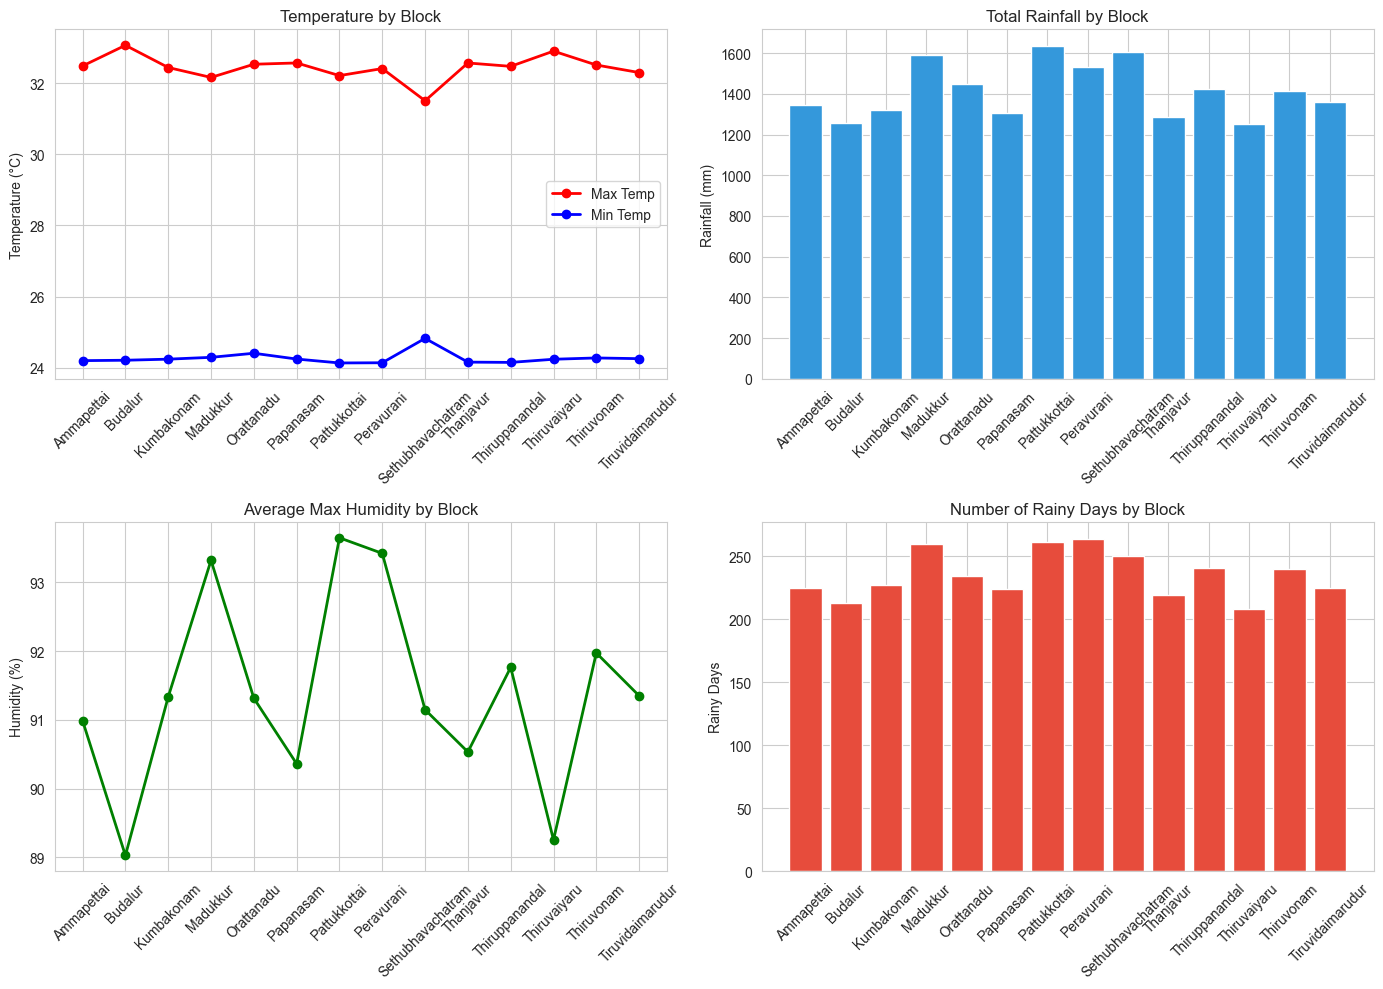

In [25]:
# Calculate average weather conditions for Thanjavur
weather_summary = ariyalur_weather[[
    'temp_max_mean', 'temp_min_mean', 'temp_mean_annual',
    'total_rainfall_mm', 'avg_daily_rainfall_mm',
    'humidity_max_mean', 'humidity_min_mean',
    'rainy_days', 'wind_speed_max_mean'
]].mean()

print("\nThanjavur Weather Summary:")
print(weather_summary.round(2))

# Create weather visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Temperature
ax = axes[0, 0]
blocks = ariyalur_weather['block'].values
ax.plot(blocks, ariyalur_weather['temp_max_mean'], 'r-o', label='Max Temp', linewidth=2)
ax.plot(blocks, ariyalur_weather['temp_min_mean'], 'b-o', label='Min Temp', linewidth=2)
ax.set_ylabel('Temperature (°C)')
ax.set_title('Temperature by Block')
ax.legend()
ax.tick_params(axis='x', rotation=45)

# Rainfall
ax = axes[0, 1]
ax.bar(blocks, ariyalur_weather['total_rainfall_mm'], color='#3498db')
ax.set_ylabel('Rainfall (mm)')
ax.set_title('Total Rainfall by Block')
ax.tick_params(axis='x', rotation=45)

# Humidity
ax = axes[1, 0]
ax.plot(blocks, ariyalur_weather['humidity_max_mean'], 'g-o', linewidth=2)
ax.set_ylabel('Humidity (%)')
ax.set_title('Average Max Humidity by Block')
ax.tick_params(axis='x', rotation=45)

# Rainy Days
ax = axes[1, 1]
ax.bar(blocks, ariyalur_weather['rainy_days'], color='#e74c3c')
ax.set_ylabel('Rainy Days')
ax.set_title('Number of Rainy Days by Block')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 8. Create Crop Suitability Scoring System

In [12]:
# Define crop requirements based on research
# Format: {crop_name: {temp_min, temp_max, rainfall_min, rainfall_max, ph_min, ph_max, n_need, p_need, k_need}}

crop_requirements = {
    'Paddy': {'temp_min': 20, 'temp_max': 35, 'rainfall_min': 1000, 'rainfall_max': 3000, 'ph_min': 5.5, 'ph_max': 8.0, 'n': 'High', 'p': 'Medium', 'k': 'Medium'},
    'Maize': {'temp_min': 18, 'temp_max': 32, 'rainfall_min': 500, 'rainfall_max': 1500, 'ph_min': 5.5, 'ph_max': 7.5, 'n': 'High', 'p': 'Medium', 'k': 'Medium'},
    'Cotton': {'temp_min': 16, 'temp_max': 30, 'rainfall_min': 600, 'rainfall_max': 1200, 'ph_min': 5.5, 'ph_max': 7.5, 'n': 'Medium', 'p': 'Medium', 'k': 'High'},
    'Sugarcane': {'temp_min': 15, 'temp_max': 35, 'rainfall_min': 750, 'rainfall_max': 2500, 'ph_min': 5.5, 'ph_max': 8.0, 'n': 'High', 'p': 'Medium', 'k': 'High'},
    'Groundnut': {'temp_min': 18, 'temp_max': 32, 'rainfall_min': 500, 'rainfall_max': 1000, 'ph_min': 5.5, 'ph_max': 7.5, 'n': 'Medium', 'p': 'High', 'k': 'High'},
    'Onion': {'temp_min': 13, 'temp_max': 28, 'rainfall_min': 400, 'rainfall_max': 800, 'ph_min': 6.0, 'ph_max': 7.5, 'n': 'High', 'p': 'High', 'k': 'High'},
    'Banana': {'temp_min': 15, 'temp_max': 35, 'rainfall_min': 1500, 'rainfall_max': 2500, 'ph_min': 6.0, 'ph_max': 8.0, 'n': 'High', 'p': 'Medium', 'k': 'High'},
    'Mango': {'temp_min': 15, 'temp_max': 35, 'rainfall_min': 400, 'rainfall_max': 2000, 'ph_min': 5.5, 'ph_max': 7.5, 'n': 'Medium', 'p': 'Medium', 'k': 'Medium'},
    'Coconut': {'temp_min': 20, 'temp_max': 35, 'rainfall_min': 1000, 'rainfall_max': 3000, 'ph_min': 5.0, 'ph_max': 8.0, 'n': 'Medium', 'p': 'Medium', 'k': 'High'},
    'Turmeric': {'temp_min': 20, 'temp_max': 32, 'rainfall_min': 800, 'rainfall_max': 2000, 'ph_min': 5.5, 'ph_max': 7.5, 'n': 'Medium', 'p': 'Medium', 'k': 'Medium'},
    'Jowar': {'temp_min': 18, 'temp_max': 32, 'rainfall_min': 400, 'rainfall_max': 1000, 'ph_min': 6.0, 'ph_max': 8.0, 'n': 'Medium', 'p': 'Medium', 'k': 'Medium'},
    'Bajra': {'temp_min': 20, 'temp_max': 32, 'rainfall_min': 300, 'rainfall_max': 700, 'ph_min': 6.0, 'ph_max': 8.0, 'n': 'Low', 'p': 'Medium', 'k': 'Medium'},
    'Red_Chillies': {'temp_min': 15, 'temp_max': 30, 'rainfall_min': 600, 'rainfall_max': 1500, 'ph_min': 5.5, 'ph_max': 7.5, 'n': 'High', 'p': 'High', 'k': 'High'},
}

print("Crop Requirements Dictionary Created")
print(f"Total crops with requirements: {len(crop_requirements)}")

Crop Requirements Dictionary Created
Total crops with requirements: 13


## 9. Calculate Crop Suitability Scores

In [13]:
def calculate_suitability_score(crop_name, soil_summary, weather_summary, crop_requirements):
    """
    Calculate suitability score for a crop based on soil and weather conditions.
    Score ranges from 0 to 100.
    """
    if crop_name not in crop_requirements:
        return None, "Crop not in requirements database"
    
    req = crop_requirements[crop_name]
    scores = []
    details = {}
    
    # Temperature compatibility (25% weight)
    temp_mean = (weather_summary['temp_max_mean'] + weather_summary['temp_min_mean']) / 2
    if req['temp_min'] <= temp_mean <= req['temp_max']:
        temp_score = 100
    elif temp_mean < req['temp_min']:
        temp_score = max(0, 100 - abs(temp_mean - req['temp_min']) * 5)
    else:
        temp_score = max(0, 100 - abs(temp_mean - req['temp_max']) * 5)
    scores.append(temp_score * 0.25)
    details['temperature'] = temp_score
    
    # Rainfall compatibility (25% weight)
    rainfall = weather_summary['total_rainfall_mm']
    if req['rainfall_min'] <= rainfall <= req['rainfall_max']:
        rainfall_score = 100
    elif rainfall < req['rainfall_min']:
        rainfall_score = max(0, 100 - abs(rainfall - req['rainfall_min']) / 10)
    else:
        rainfall_score = max(0, 100 - abs(rainfall - req['rainfall_max']) / 10)
    scores.append(rainfall_score * 0.25)
    details['rainfall'] = rainfall_score
    
    # Soil Nitrogen (10% weight)
    if req['n'] == 'High':
        n_score = soil_summary['n_High']
    elif req['n'] == 'Medium':
        n_score = soil_summary['n_Medium'] + soil_summary['n_High'] * 0.5
    else:  # Low
        n_score = 100 - soil_summary['n_High']
    scores.append((min(n_score, 100)) * 0.10)
    details['nitrogen'] = min(n_score, 100)
    
    # Soil Phosphorus (10% weight)
    if req['p'] == 'High':
        p_score = soil_summary['p_High']
    elif req['p'] == 'Medium':
        p_score = soil_summary['p_Medium'] + soil_summary['p_High'] * 0.5
    else:  # Low
        p_score = 100 - soil_summary['p_High']
    scores.append((min(p_score, 100)) * 0.10)
    details['phosphorus'] = min(p_score, 100)
    
    # Soil Potassium (10% weight)
    if req['k'] == 'High':
        k_score = soil_summary['k_High']
    elif req['k'] == 'Medium':
        k_score = soil_summary['k_Medium'] + soil_summary['k_High'] * 0.5
    else:  # Low
        k_score = 100 - soil_summary['k_High']
    scores.append((min(k_score, 100)) * 0.10)
    details['potassium'] = min(k_score, 100)
    
    # pH compatibility (5% weight)
    ph = 6.8  # Average neutral pH
    if req['ph_min'] <= ph <= req['ph_max']:
        ph_score = 100
    else:
        ph_score = max(0, 100 - abs(ph - req['ph_min'] if ph < req['ph_min'] else ph - req['ph_max']) * 20)
    scores.append(ph_score * 0.05)
    details['pH'] = ph_score
    
    total_score = sum(scores)
    
    return total_score, details

print("Suitability Scoring Function Created")

Suitability Scoring Function Created


## 10. Calculate Scores for All Crops

In [ ]:
# Get Thanjavur specific data
ariyalur_soil = soil_summary.loc['THANJAVUR']

# Calculate scores for all crops
crop_scores = []
crop_details = {}

for crop_name in crop_requirements.keys():
    score, details = calculate_suitability_score(crop_name, ariyalur_soil, weather_summary, crop_requirements)
    crop_scores.append({
        'Crop': crop_name,
        'Suitability Score': score
    })
    crop_details[crop_name] = details

# Create results dataframe
scores_df = pd.DataFrame(crop_scores).sort_values('Suitability Score', ascending=False)

print("\n" + "="*60)
print("CROP SUITABILITY SCORES FOR THANJAVUR DISTRICT")
print("="*60)
print(scores_df.to_string(index=False))

# Highlight top 5 recommendations
print("\n" + "="*60)
print("TOP 5 RECOMMENDED CROPS FOR MAXIMUM YIELD")
print("="*60)
top_5 = scores_df.head(5)
for idx, row in top_5.iterrows():
    print(f"\n{idx+1}. {row['Crop']}")
    print(f"   Suitability Score: {row['Suitability Score']:.2f}/100")
    details = crop_details[row['Crop']]
    print(f"   Temperature Match: {details['temperature']:.1f}/100")
    print(f"   Rainfall Match: {details['rainfall']:.1f}/100")
    print(f"   Nitrogen Availability: {details['nitrogen']:.1f}/100")
    print(f"   Phosphorus Availability: {details['phosphorus']:.1f}/100")
    print(f"   Potassium Availability: {details['potassium']:.1f}/100")

## 11. Visualize Crop Suitability Scores

In [ ]:
# Create visualization
fig, ax = plt.subplots(figsize=(12, 8))

# Color code by score
colors = ['#27ae60' if score >= 70 else '#f39c12' if score >= 50 else '#e74c3c' 
          for score in scores_df['Suitability Score']]

bars = ax.barh(scores_df['Crop'], scores_df['Suitability Score'], color=colors)
ax.set_xlabel('Suitability Score (0-100)', fontsize=12, fontweight='bold')
ax.set_title('Crop Suitability Scores for Thanjavur District', fontsize=14, fontweight='bold')
ax.set_xlim(0, 100)

# Add value labels
for i, (idx, row) in enumerate(scores_df.iterrows()):
    ax.text(row['Suitability Score'] + 1, i, f"{row['Suitability Score']:.1f}", 
            va='center', fontweight='bold')

# Add reference lines
ax.axvline(x=70, color='green', linestyle='--', alpha=0.5, label='Highly Suitable (≥70)')
ax.axvline(x=50, color='orange', linestyle='--', alpha=0.5, label='Moderately Suitable (50-70)')
ax.axvline(x=30, color='red', linestyle='--', alpha=0.5, label='Low Suitability (<50)')

ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 12. Detailed Analysis - Top Recommended Crops

In [ ]:
# Create detailed comparison for top 5 crops
top_crops = scores_df.head(5)['Crop'].tolist()

detail_data = []
for crop in top_crops:
    details = crop_details[crop]
    detail_data.append({
        'Crop': crop,
        'Temperature': details['temperature'],
        'Rainfall': details['rainfall'],
        'Nitrogen': details['nitrogen'],
        'Phosphorus': details['phosphorus'],
        'Potassium': details['potassium'],
        'pH': details['pH'],
        'Overall': scores_df[scores_df['Crop']==crop]['Suitability Score'].values[0]
    })

detail_df = pd.DataFrame(detail_data)

fig, ax = plt.subplots(figsize=(12, 6))

# Create grouped bar chart
x = np.arange(len(detail_df))
width = 0.12

metrics = ['Temperature', 'Rainfall', 'Nitrogen', 'Phosphorus', 'Potassium', 'pH']
colors_bar = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

for i, metric in enumerate(metrics):
    ax.bar(x + i * width, detail_df[metric], width, label=metric, color=colors_bar[i])

ax.set_xlabel('Crops', fontsize=12, fontweight='bold')
ax.set_ylabel('Score (0-100)', fontsize=12, fontweight='bold')
ax.set_title('Detailed Suitability Scores - Top 5 Recommended Crops', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 2.5)
ax.set_xticklabels(detail_df['Crop'])
ax.legend(loc='upper left', ncol=3)
ax.set_ylim(0, 110)

plt.tight_layout()
plt.show()

print("\nDetailed Scores for Top 5 Crops:")
print(detail_df.round(2).to_string(index=False))

## 13. Load and Analyze Historical Price Data for Top Crops

In [26]:
# Extract crops available in Thanjavur district
print("="*60)
print("CROPS AVAILABLE IN THANJAVUR DISTRICT (From Market Data)")
print("="*60)

ariyalur_crops = {}
ariyalur_crop_details = {}

for crop_name, crop_df in crop_data_dict.items():
    # Filter for Thanjavur district
    ariyalur_data = crop_df[crop_df['District Name'] == 'Thanjavur']
    
    if len(ariyalur_data) > 0:
        ariyalur_crops[crop_name] = ariyalur_data
        
        # Calculate statistics
        avg_price = ariyalur_data['Modal Price (Rs./Quintal)'].mean()
        median_price = ariyalur_data['Modal Price (Rs./Quintal)'].median()
        min_price = ariyalur_data['Modal Price (Rs./Quintal)'].min()
        max_price = ariyalur_data['Modal Price (Rs./Quintal)'].max()
        num_records = len(ariyalur_data)
        
        ariyalur_crop_details[crop_name] = {
            'avg_price': avg_price,
            'median_price': median_price,
            'min_price': min_price,
            'max_price': max_price,
            'num_records': num_records,
            'price_std': ariyalur_data['Modal Price (Rs./Quintal)'].std(),
            'date_range': f"{ariyalur_data['Price Date'].min()} to {ariyalur_data['Price Date'].max()}"
        }

print(f"\nTotal crops found in Thanjavur: {len(ariyalur_crops)}")
print(f"\nCrops with market data in Thanjavur:")

# Display as table
crop_summary = []
for crop_name, details in ariyalur_crop_details.items():
    crop_summary.append({
        'Crop': crop_name,
        'Avg Price (Rs./Qt)': f"{details['avg_price']:.0f}",
        'Market Records': details['num_records'],
        'Date Range': details['date_range']
    })

crop_summary_df = pd.DataFrame(crop_summary).sort_values('Market Records', ascending=False)
print(crop_summary_df.to_string(index=False))

# Store list of available crops
available_crops_in_ariyalur = list(ariyalur_crops.keys())
print(f"\n\nAvailable Crops: {', '.join(available_crops_in_ariyalur)}")

CROPS AVAILABLE IN THANJAVUR DISTRICT (From Market Data)

Total crops found in Thanjavur: 19

Crops with market data in Thanjavur:
             Crop Avg Price (Rs./Qt)  Market Records               Date Range
  Paddy-2019-2022               1942            1573 2019-01-01 to 2021-12-31
   Banana - Green               3512            1561 2024-06-18 to 2025-07-21
            Onion               4673            1558 2024-06-18 to 2025-07-21
           Banana               5668            1554 2024-06-18 to 2025-07-21
       Corriander               3653            1511 2024-06-18 to 2025-07-21
   Mango-Raw-Ripe               5940            1345 2024-06-18 to 2025-07-21
            Lemon               8336            1198 2024-06-18 to 2025-07-21
           Garlic              22073            1030 2024-06-18 to 2025-07-21
  Paddy-2022-2025               1984             951 2022-01-03 to 2025-07-21
Coconut-2024-2025               3974             786 2024-06-18 to 2025-01-01
     Coconu

## 14. Data-Driven Scoring: Combining Soil, Weather & Market Performance

In [27]:
# Create enhanced scoring system using soil, weather, AND market data
def enhanced_suitability_score(crop_name, soil_summary, weather_summary, crop_requirements, 
                                market_details, base_weight=0.7, market_weight=0.3):
    """
    Calculate suitability score using:
    - 70% Soil & Weather conditions
    - 30% Market performance (price trends, frequency of trading)
    """
    
    # Get base score from soil & weather
    base_score, details = calculate_suitability_score(crop_name, soil_summary, weather_summary, crop_requirements)
    
    if base_score is None:
        return None, details
    
    # Get market score
    market_details_crop = market_details.get(crop_name, None)
    
    if market_details_crop is None:
        # Crop not grown in Ariyalur - lower score
        market_score = 20
        details['market_fitness'] = market_score
        details['notes'] = "Crop NOT found in Ariyalur market data - risky choice"
    else:
        # Crop is grown in Ariyalur - calculate market score
        num_records = market_details_crop['num_records']
        price_stability = 100 - min(market_details_crop['price_std'] / market_details_crop['mean_price'] * 100, 100) if market_details_crop['mean_price'] > 0 else 50
        
        # Market score components
        # 1. Record frequency (more records = more established crop)
        frequency_score = min((num_records / 200) * 100, 100)  # Normalize to 100 if 200+ records
        
        # 2. Price stability (less price variation = more predictable)
        stability_score = price_stability
        
        # 3. Market presence (any records means it's actively traded)
        market_presence = 100
        
        market_score = (frequency_score * 0.4 + stability_score * 0.3 + market_presence * 0.3)
        details['market_fitness'] = market_score
        details['price_stability'] = stability_score
        details['market_records'] = num_records
        details['avg_price'] = market_details_crop['mean_price']
        details['notes'] = f"Established crop with {num_records} market records in Ariyalur"
    
    # Combine scores
    final_score = (base_score * base_weight) + (market_score * market_weight)
    
    return final_score, details

# Prepare market details summary
market_summary = {}
for crop_name, details in ariyalur_crop_details.items():
    market_summary[crop_name] = {
        'num_records': details['num_records'],
        'mean_price': details['avg_price'],
        'price_std': details['price_std'],
        'price_range': details['max_price'] - details['min_price']
    }

print("Enhanced Scoring System Created")
print(f"Market data available for {len(market_summary)} crops")

Enhanced Scoring System Created
Market data available for 19 crops


## 15. Generate Final Recommendations Using All Data Sources

In [28]:
# Calculate enhanced scores for all available crops
print("="*70)
print("FINAL CROP RECOMMENDATIONS FOR THANJAVUR DISTRICT")
print("="*70)

# Ensure we have the required variables
if 'ariyalur_soil' not in locals():
    ariyalur_soil = soil_summary.loc['Ariyalur']

enhanced_scores = []
enhanced_details = {}

# Score all crops with market data (from cleaned CSVs)
for crop_name in available_crops_in_ariyalur:
    if crop_name in crop_requirements:
        score, details = enhanced_suitability_score(
            crop_name, ariyalur_soil, weather_summary, crop_requirements, 
            market_summary, base_weight=0.7, market_weight=0.3
        )
        enhanced_scores.append({
            'Crop': crop_name,
            'Score': score,
            'Data Source': 'Actual Market Data'
        })
        enhanced_details[crop_name] = details

# Also score crops from requirements that aren't in market data
for crop_name in crop_requirements.keys():
    if crop_name not in available_crops_in_ariyalur:
        score, details = enhanced_suitability_score(
            crop_name, ariyalur_soil, weather_summary, crop_requirements, 
            market_summary, base_weight=0.95, market_weight=0.05  # Less weight on market since no data
        )
        enhanced_scores.append({
            'Crop': crop_name,
            'Score': score,
            'Data Source': 'Soil/Weather Est.'
        })
        enhanced_details[crop_name] = details

# Sort by score
final_scores_df = pd.DataFrame(enhanced_scores).sort_values('Score', ascending=False)

print("\nAll Crops Ranked by Suitability:\n")
print(final_scores_df.to_string(index=False))

# Highlight top 10 recommendations
print("\n\n" + "="*70)
print("TOP 10 RECOMMENDED CROPS FOR THANJAVUR - MAXIMUM YIELD POTENTIAL")
print("="*70)

top_10 = final_scores_df.head(10)
for rank, (idx, row) in enumerate(top_10.iterrows(), 1):
    crop_name = row['Crop']
    score = row['Score']
    source = row['Data Source']
    details = enhanced_details[crop_name]
    
    print(f"\n{'='*70}")
    print(f"#{rank} - {crop_name.upper()}")
    print(f"{'='*70}")
    print(f"Overall Suitability Score: {score:.2f}/100")
    print(f"Data Source: {source}")
    
    if 'notes' in details:
        print(f"Notes: {details['notes']}")
    
    print(f"\nScoring Breakdown:")
    print(f"  • Temperature Match: {details['temperature']:.1f}/100")
    print(f"  • Rainfall Match: {details['rainfall']:.1f}/100")
    print(f"  • Nitrogen Availability: {details['nitrogen']:.1f}/100")
    print(f"  • Phosphorus Availability: {details['phosphorus']:.1f}/100")
    print(f"  • Potassium Availability: {details['potassium']:.1f}/100")
    print(f"  • pH Suitability: {details['pH']:.1f}/100")
    
    if 'market_fitness' in details:
        print(f"  • Market Fitness: {details['market_fitness']:.1f}/100")
    
    if 'avg_price' in details:
        print(f"\nMarket Information:")
        print(f"  • Average Market Price: Rs. {details['avg_price']:.0f}/Quintal")
        print(f"  • Price Stability: {details['price_stability']:.1f}/100")
        print(f"  • Market Records: {details['market_records']}")

print("\n\n" + "="*70)
print("RECOMMENDATION SUMMARY")
print("="*70)
print(f"\n✓ Top Recommended Crop: {top_10.iloc[0]['Crop']}")
print(f"  Score: {top_10.iloc[0]['Score']:.2f}/100")
print(f"\n✓ Most Data-Backed Crops (with actual market history):")
data_backed = final_scores_df[final_scores_df['Data Source'] == 'Actual Market Data'].head(5)
for idx, (i, row) in enumerate(data_backed.iterrows(), 1):
    print(f"  {idx}. {row['Crop']} - Score: {row['Score']:.2f}/100")

FINAL CROP RECOMMENDATIONS FOR THANJAVUR DISTRICT

All Crops Ranked by Suitability:

        Crop     Score        Data Source
       Mango 76.304542 Actual Market Data
    Turmeric 72.122858  Soil/Weather Est.
       Paddy 72.121750  Soil/Weather Est.
       Maize 72.121750  Soil/Weather Est.
      Banana 70.455472 Actual Market Data
      Cotton 69.181626 Actual Market Data
       Bajra 64.708368  Soil/Weather Est.
     Coconut 62.639483  Soil/Weather Est.
   Sugarcane 62.638375  Soil/Weather Est.
       Jowar 62.337010  Soil/Weather Est.
       Onion 54.242557 Actual Market Data
Red_Chillies 53.459317  Soil/Weather Est.
   Groundnut 51.934977 Actual Market Data


TOP 10 RECOMMENDED CROPS FOR THANJAVUR - MAXIMUM YIELD POTENTIAL

#1 - MANGO
Overall Suitability Score: 76.30/100
Data Source: Actual Market Data
Notes: Established crop with 464 market records in Ariyalur

Scoring Breakdown:
  • Temperature Match: 100.0/100
  • Rainfall Match: 100.0/100
  • Nitrogen Availability: 0.0/100
 